patient-level stratified 5-fold cross validation

# Full image CNN

In [3]:
import pandas as pd
import shutil
from pathlib import Path
from sklearn.model_selection import StratifiedKFold

# ==========================================
# CONFIG
# ==========================================
LABEL_PATH = "Labels.csv"
IMAGESET_PATH = "HYGD"
SPLIT_PATH = "image_cv_split"

N_SPLITS = 5
RANDOM_STATE = 42

# ==========================================
# LOAD & PREPARE DATA
# ==========================================
df = pd.read_csv(LABEL_PATH)

# optional cleanup
df = df.drop(columns=["Unnamed: 4"], errors="ignore")

# label encoding
df["label_numeric"] = df["Label"].map({"GON+": 1, "GON-": 0})

# full image path
df["Filename"] = df["Image Name"].apply(lambda x: (Path(IMAGESET_PATH) / x).as_posix())

# ==========================================
# BASIC CHECKS
# ==========================================
# 1) check missing labels
if df["label_numeric"].isna().any():
    bad_rows = df[df["label_numeric"].isna()][["Image Name", "Label", "Patient"]]
    raise ValueError(
        "Found unmapped labels in Label column. Check these rows:\n"
        f"{bad_rows.head(10)}"
    )

# 2) check each patient has only one label
patient_label_check = df.groupby("Patient")["label_numeric"].nunique()
bad_patients = patient_label_check[patient_label_check > 1]

if len(bad_patients) > 0:
    raise ValueError(
        "Some patients have inconsistent labels across images. "
        f"Problematic patients: {bad_patients.index.tolist()[:10]}"
    )

# ==========================================
# BUILD PATIENT-LEVEL TABLE
# ==========================================
patient_df = (
    df.groupby("Patient", as_index=False)
      .agg(label_numeric=("label_numeric", "first"))
)

print("===== PATIENT-LEVEL SUMMARY =====")
print("Total images   :", len(df))
print("Total patients :", len(patient_df))
print("Patient label distribution:")
print(patient_df["label_numeric"].value_counts().sort_index())
print()

# ==========================================
# STRATIFIED K-FOLD ON PATIENTS
# ==========================================
skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# ==========================================
# HELPER: COPY IMAGES
# ==========================================
def copy_images(dataframe, split_dir):
    """
    Copy images into:
      split_dir/GON+/
      split_dir/GON-/
    """
    total = len(dataframe)
    copied = 0
    missing = 0

    for _, row in dataframe.iterrows():
        src = Path(row["Filename"])
        dst = Path(split_dir) / row["Label"] / src.name

        if src.exists():
            shutil.copy(src, dst)
            copied += 1
        else:
            print(f"  ⚠️ Missing: {src}")
            missing += 1

    return copied, missing

# ==========================================
# GENERATE ALL FOLDS
# ==========================================
for fold_idx, (train_idx, val_idx) in enumerate(
    skf.split(patient_df["Patient"], patient_df["label_numeric"]),
    start=1
):
    print(f"===== FOLD {fold_idx} =====")

    train_patients = patient_df.iloc[train_idx]["Patient"]
    val_patients = patient_df.iloc[val_idx]["Patient"]

    # map back to image-level rows
    train_df = df[df["Patient"].isin(train_patients)].copy()
    val_df = df[df["Patient"].isin(val_patients)].copy()

    # leakage check
    overlap = set(train_df["Patient"]).intersection(set(val_df["Patient"]))
    if len(overlap) > 0:
        raise ValueError(f"Patient leakage detected in fold {fold_idx}: {list(overlap)[:10]}")

    print(f"Train patients: {train_df['Patient'].nunique()}, images: {len(train_df)}")
    print(f"Val patients  : {val_df['Patient'].nunique()}, images: {len(val_df)}")

    print("Train label distribution:")
    print(train_df["label_numeric"].value_counts().sort_index())

    print("Val label distribution:")
    print(val_df["label_numeric"].value_counts().sort_index())

    # folder structure
    fold_root = Path(SPLIT_PATH) / f"fold_{fold_idx}"
    train_root = fold_root / "train"
    val_root = fold_root / "val"

    for split_root in [train_root, val_root]:
        for label in ["GON+", "GON-"]:
            (split_root / label).mkdir(parents=True, exist_ok=True)

    # save fold CSV
    train_df.to_csv(fold_root / f"train_fold{fold_idx}.csv", index=False)
    val_df.to_csv(fold_root / f"val_fold{fold_idx}.csv", index=False)

    # copy train images
    print(f"Copying train images for fold {fold_idx}...")
    copied_train, missing_train = copy_images(train_df, train_root)

    # copy val images
    print(f"Copying val images for fold {fold_idx}...")
    copied_val, missing_val = copy_images(val_df, val_root)

    print(
        f"✅ Fold {fold_idx} done | "
        f"train: {copied_train} copied, {missing_train} missing | "
        f"val: {copied_val} copied, {missing_val} missing\n"
    )

print("🎉 All folds generated successfully.")

===== PATIENT-LEVEL SUMMARY =====
Total images   : 747
Total patients : 288
Patient label distribution:
label_numeric
0    102
1    186
Name: count, dtype: int64

===== FOLD 1 =====
Train patients: 230, images: 591
Val patients  : 58, images: 156
Train label distribution:
label_numeric
0    157
1    434
Name: count, dtype: int64
Val label distribution:
label_numeric
0     42
1    114
Name: count, dtype: int64
Copying train images for fold 1...
Copying val images for fold 1...
✅ Fold 1 done | train: 591 copied, 0 missing | val: 156 copied, 0 missing

===== FOLD 2 =====
Train patients: 230, images: 599
Val patients  : 58, images: 148
Train label distribution:
label_numeric
0    157
1    442
Name: count, dtype: int64
Val label distribution:
label_numeric
0     42
1    106
Name: count, dtype: int64
Copying train images for fold 2...
Copying val images for fold 2...
✅ Fold 2 done | train: 599 copied, 0 missing | val: 148 copied, 0 missing

===== FOLD 3 =====
Train patients: 230, images: 619

Step 2: Initialise CNN parameters

In [8]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch
import timm
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
from pathlib import Path

# ==========================================
# PREPROCESSING PARAMETERS
# ==========================================
IMG_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# ==========================================
# MODEL PARAMETERS
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL = "resnet18"
NUM_CLASSES = 1

# ==========================================
# TRAINING PARAMETERS
# ==========================================
BATCH_SIZE = 16
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 0.001
NUM_EPOCHS = 15

# ==========================================
# CV PATH
# ==========================================
CV_ROOT = Path("image_cv_split")
N_FOLDS = 5

# ==========================================
# IMAGE PREPROCESS & AUGMENTATIONS
# ==========================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ==========================================
# BUILD DATALOADERS FOR ONE FOLD
# ==========================================
def build_dataloaders_for_fold(fold_idx, batch_size=BATCH_SIZE):
    train_path = CV_ROOT / f"fold_{fold_idx}" / "train"
    val_path   = CV_ROOT / f"fold_{fold_idx}" / "val"

    if not train_path.exists():
        raise FileNotFoundError(f"Train path not found: {train_path}")
    if not val_path.exists():
        raise FileNotFoundError(f"Val path not found: {val_path}")

    train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
    val_dataset   = datasets.ImageFolder(val_path, transform=val_transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    print(f"===== FOLD {fold_idx} DATALOADER SUMMARY =====")
    print("Train path:", train_path)
    print("Val path  :", val_path)
    print("Train size:", len(train_dataset))
    print("Val size  :", len(val_dataset))
    print("Class to index:", train_dataset.class_to_idx)
    print()

    return train_dataset, val_dataset, train_loader, val_loader

Initialise model & train script

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np

def build_model_components():
    model = timm.create_model(
        MODEL,
        pretrained=True,
        num_classes=NUM_CLASSES
    )
    model = model.to(DEVICE)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    return model, criterion, optimizer, scheduler


def train_one_epoch(model, criterion, optimizer, dataloader):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE).float()

        optimizer.zero_grad()

        outputs = model(inputs).squeeze(1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).long()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.long()).item()

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects / len(dataloader.dataset)

    return epoch_loss, epoch_acc


def validate_one_epoch(model, criterion, dataloader):
    model.eval()
    running_loss = 0.0
    running_corrects = 0

    all_labels = []
    all_probs = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE).float()

            outputs = model(inputs).squeeze(1)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).long()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.long()).item()

            all_labels.extend(labels.cpu().numpy().astype(int).tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects / len(dataloader.dataset)

    return epoch_loss, epoch_acc, all_labels, all_probs, all_preds

Run training

In [13]:
import os
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score, confusion_matrix, f1_score, accuracy_score

print("5-fold model training commences...\n")

# ==========================================
# OUTPUT PATHS
# ==========================================
OUTPUT_ROOT = Path("cnn_cv_outputs")
MODEL_ROOT = OUTPUT_ROOT / "models"
MODEL_ROOT.mkdir(parents=True, exist_ok=True)

all_fold_results = []
all_oof_rows = []

# ==========================================
# METRIC FUNCTION
# ==========================================
def compute_binary_metrics(y_true, y_prob, y_pred):
    auc = roc_auc_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = f1_score(y_true, y_pred)

    return {
        "accuracy": acc,
        "auroc": auc,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

# ==========================================
# MAIN 5-FOLD LOOP
# ==========================================
for fold_idx in range(1, N_FOLDS + 1):
    print(f"\n{'='*50}")
    print(f"FOLD {fold_idx}/{N_FOLDS}")
    print(f"{'='*50}")

    # ----------------------------
    # 1. Build fold dataloaders
    # ----------------------------
    train_dataset, val_dataset, train_loader, val_loader = build_dataloaders_for_fold(fold_idx)

    # IMPORTANT: check class mapping
    print("Class mapping:", train_dataset.class_to_idx)

    # ----------------------------
    # 2. Fresh model for this fold
    # ----------------------------
    model, criterion, optimizer, scheduler = build_model_components()

    # fold-specific save paths
    best_path = MODEL_ROOT / f"best_model_fold{fold_idx}.pth"
    last_path = MODEL_ROOT / f"last_model_fold{fold_idx}.pth"

    best_val_loss = float("inf")
    best_epoch = -1

    history_rows = []

    # ----------------------------
    # 3. Epoch loop
    # ----------------------------
    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-" * 30)

        train_loss, train_acc = train_one_epoch(model, criterion, optimizer, train_loader)

        val_loss, val_acc, y_true, y_prob, y_pred = validate_one_epoch(
            model, criterion, val_loader
        )

        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

        history_rows.append({
            "fold": fold_idx,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        # save best model for this fold
        if val_loss < best_val_loss:
            print(f"🌟 Val loss decreased ({best_val_loss:.4f} --> {val_loss:.4f}). Saving model...")
            torch.save(model.state_dict(), best_path)
            print(f"Best model saved to {best_path}")
            best_val_loss = val_loss
            best_epoch = epoch + 1

    # save last model for this fold
    torch.save(model.state_dict(), last_path)
    print(f"\nLast model saved to {last_path}")

    # ----------------------------
    # 4. Reload BEST model and evaluate fold
    # ----------------------------
    model, criterion, optimizer, scheduler = build_model_components()
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    model = model.to(DEVICE)

    val_loss, val_acc, y_true, y_prob, y_pred = validate_one_epoch(
        model, criterion, val_loader
    )

    fold_metrics = compute_binary_metrics(y_true, y_prob, y_pred)
    fold_metrics["fold"] = fold_idx
    fold_metrics["best_epoch"] = best_epoch
    fold_metrics["best_val_loss"] = best_val_loss
    fold_metrics["n_val_images"] = len(val_dataset)

    all_fold_results.append(fold_metrics)

    print("\nFold final metrics (best model):")
    for k, v in fold_metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

    # ----------------------------
    # 5. Save OOF predictions
    # ----------------------------
    val_samples = val_dataset.samples   # [(path, class_idx), ...]

    if len(val_samples) != len(y_true):
        print("⚠️ Warning: val_samples length does not match prediction length.")
    else:
        for i, ((img_path, class_idx), true_label, prob, pred) in enumerate(
            zip(val_samples, y_true, y_prob, y_pred)
        ):
            all_oof_rows.append({
                "fold": fold_idx,
                "image_path": img_path,
                "image_name": Path(img_path).name,
                "true_label": true_label,
                "pred_prob": prob,
                "pred_label": pred,
            })

    # ----------------------------
    # 6. Save fold history
    # ----------------------------
    fold_history_df = pd.DataFrame(history_rows)
    fold_history_df.to_csv(OUTPUT_ROOT / f"training_history_fold{fold_idx}.csv", index=False)

print("\n🎉 5-fold training complete!")

# ==========================================
# SAVE FINAL RESULTS
# ==========================================
results_df = pd.DataFrame(all_fold_results)
results_df.to_csv(OUTPUT_ROOT / "cnn_5fold_results.csv", index=False)

summary_df = results_df.drop(columns=["fold"]).agg(["mean", "std"]).T.reset_index()
summary_df.columns = ["metric", "mean", "std"]
summary_df.to_csv(OUTPUT_ROOT / "cnn_5fold_summary.csv", index=False)

oof_df = pd.DataFrame(all_oof_rows)
oof_df.to_csv(OUTPUT_ROOT / "cnn_oof_predictions_5fold.csv", index=False)

print("\nSaved:")
print(OUTPUT_ROOT / "cnn_5fold_results.csv")
print(OUTPUT_ROOT / "cnn_5fold_summary.csv")
print(OUTPUT_ROOT / "cnn_oof_predictions_5fold.csv")

5-fold model training commences...


FOLD 1/5
===== FOLD 1 DATALOADER SUMMARY =====
Train path: image_cv_split\fold_1\train
Val path  : image_cv_split\fold_1\val
Train size: 591
Val size  : 156
Class to index: {'GON+': 0, 'GON-': 1}

Class mapping: {'GON+': 0, 'GON-': 1}

Epoch 1/15
------------------------------
Train Loss: 0.4680 | Train Acc: 0.7479
Val   Loss: 0.3526 | Val   Acc: 0.8462
🌟 Val loss decreased (inf --> 0.3526). Saving model...
Best model saved to cnn_cv_outputs\models\best_model_fold1.pth

Epoch 2/15
------------------------------
Train Loss: 0.2098 | Train Acc: 0.9408
Val   Loss: 0.1498 | Val   Acc: 0.9487
🌟 Val loss decreased (0.3526 --> 0.1498). Saving model...
Best model saved to cnn_cv_outputs\models\best_model_fold1.pth

Epoch 3/15
------------------------------
Train Loss: 0.1275 | Train Acc: 0.9594
Val   Loss: 0.2469 | Val   Acc: 0.8846

Epoch 4/15
------------------------------
Train Loss: 0.0964 | Train Acc: 0.9712
Val   Loss: 0.1545 | Val   Acc: 0.9423

Epoc

#### Cross-validated performance on full image data

In [1]:
import pandas as pd

cnn_df = pd.read_csv("cnn_cv_outputs/cnn_5fold_results_for_comparison.csv")

def mean_std_str(series):
    return f"{series.mean():.3f} ± {series.std(ddof=1):.3f}"

cnn_summary = pd.DataFrame({
    "Feature": ["CNN (ResNet18)"],
    "AUROC": [mean_std_str(cnn_df["auroc"])],
    "Sensitivity (R+)": [mean_std_str(cnn_df["specificity"])], #<--- labels were accidentally swapped, specificity and sensitivity were swapped as a quick patch
    "Specificity (R-)": [mean_std_str(cnn_df["sensitivity"])],
    "Accuracy": [mean_std_str(cnn_df["accuracy"])],
    "PR-AUC": [mean_std_str(cnn_df["pr_auc"])],
    "F1": [mean_std_str(cnn_df["f1"])],
})

print("=" * 130)
print("Final patient-level Stratified 5-Fold CV results")
print(cnn_summary.to_string(index=False))

cnn_summary.to_csv("cnn_cv_outputs/cnn_final_summary_table_complete.csv", index=False)
print("=" * 130)

Final patient-level Stratified 5-Fold CV results
       Feature         AUROC Sensitivity (R+) Specificity (R-)      Accuracy        PR-AUC            F1
CNN (ResNet18) 0.993 ± 0.006    0.981 ± 0.015    0.942 ± 0.066 0.970 ± 0.020 0.983 ± 0.013 0.943 ± 0.039


Out-Of-Fold Classification Report
              precision    recall  f1-score   support

        GON+       0.98      0.98      0.98       548
        GON-       0.94      0.94      0.94       199

    accuracy                           0.97       747
   macro avg       0.96      0.96      0.96       747
weighted avg       0.97      0.97      0.97       747



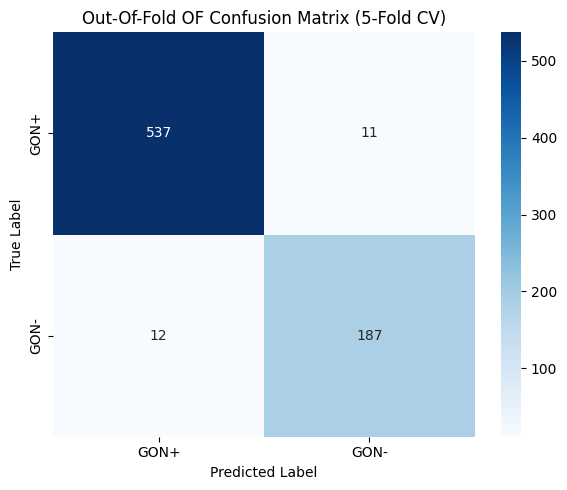

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

oof_df = pd.read_csv("cnn_cv_outputs/cnn_oof_predictions_5fold.csv")

y_true = oof_df["true_label"]
y_pred = oof_df["pred_label"]

class_names = ["GON+", "GON-"]

cm = confusion_matrix(y_true, y_pred)

print("=" * 90)
print("Out-Of-Fold Classification Report")
print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Out-Of-Fold OF Confusion Matrix (5-Fold CV)")
plt.tight_layout()
plt.show()

### Cross-validation was repeated with ROI cropped & ROI masked dataset


#### ROI cropped dataset

In [ ]:
#patient-level stratified 5-fold cross validation
import pandas as pd
import shutil
from pathlib import Path
from sklearn.model_selection import StratifiedKFold

# ==========================================
# CONFIG
# ==========================================
LABEL_PATH = "Labels.csv"
ROI_ROOT = Path("ROI")
SPLIT_PATH = "roi_cropped_cv_split"

N_SPLITS = 5
RANDOM_STATE = 42

# ==========================================
# LOAD & PREPARE DATA
# ==========================================
df = pd.read_csv(LABEL_PATH)
df = df.drop(columns=["Unnamed: 4"], errors="ignore")

df["Image Name"] = df["Image Name"].astype(str).str.strip()
df["label_numeric"] = df["Label"].map({"GON+": 1, "GON-": 0})

# ==========================================
# BUILD REAL ROI PATH FROM LABEL
# GON+ -> ROI/positive
# GON- -> ROI/negative
# ==========================================
def build_roi_path(row):
    if row["Label"] == "GON+":
        return ROI_ROOT / "positive" / row["Image Name"]
    elif row["Label"] == "GON-":
        return ROI_ROOT / "negative" / row["Image Name"]
    else:
        return None

df["Filename"] = df.apply(build_roi_path, axis=1)

# ==========================================
# CHECKS
# ==========================================
if df["label_numeric"].isna().any():
    bad_rows = df[df["label_numeric"].isna()][["Image Name", "Label", "Patient"]]
    raise ValueError(f"Found unmapped labels:\n{bad_rows.head(10)}")

missing_mask = df["Filename"].isna() | ~df["Filename"].apply(lambda p: Path(p).exists())

print("Total rows:", len(df))
print("Matched ROI files:", (~missing_mask).sum())
print("Missing ROI files:", missing_mask.sum())

if missing_mask.sum() > 0:
    print("\nFirst 20 missing ROI image names:")
    print(df.loc[missing_mask, ["Image Name", "Label", "Filename"]].head(20))


df = df.loc[~missing_mask].copy()

# ==========================================
# PATIENT CONSISTENCY CHECK
# ==========================================
patient_label_check = df.groupby("Patient")["label_numeric"].nunique()
bad_patients = patient_label_check[patient_label_check > 1]
if len(bad_patients) > 0:
    raise ValueError(
        f"Some patients have inconsistent labels: {bad_patients.index.tolist()[:10]}"
    )

# patient-level table
patient_df = (
    df.groupby("Patient", as_index=False)
      .agg(label_numeric=("label_numeric", "first"))
)

print("\n===== PATIENT-LEVEL SUMMARY =====")
print("Total ROI images :", len(df))
print("Total patients   :", len(patient_df))
print("Patient label distribution:")
print(patient_df["label_numeric"].value_counts().sort_index())

# ==========================================
# STRATIFIED K-FOLD ON PATIENTS
# ==========================================
skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

def copy_images(dataframe, split_dir):
    total = len(dataframe)
    copied = 0
    missing = 0

    for _, row in dataframe.iterrows():
        src = Path(row["Filename"])
        dst = Path(split_dir) / row["Label"] / src.name

        if src.exists():
            shutil.copy(src, dst)
            copied += 1
        else:
            missing += 1

    return copied, missing

# ==========================================
# GENERATE ALL FOLDS
# ==========================================
for fold_idx, (train_idx, val_idx) in enumerate(
    skf.split(patient_df["Patient"], patient_df["label_numeric"]),
    start=1
):
    print(f"\n===== FOLD {fold_idx} =====")

    train_patients = patient_df.iloc[train_idx]["Patient"]
    val_patients = patient_df.iloc[val_idx]["Patient"]

    train_df = df[df["Patient"].isin(train_patients)].copy()
    val_df = df[df["Patient"].isin(val_patients)].copy()

    overlap = set(train_df["Patient"]).intersection(set(val_df["Patient"]))
    if len(overlap) > 0:
        raise ValueError(f"Patient leakage detected in fold {fold_idx}: {list(overlap)[:10]}")

    print(f"Train patients: {train_df['Patient'].nunique()}, images: {len(train_df)}")
    print(f"Val patients  : {val_df['Patient'].nunique()}, images: {len(val_df)}")

    print("Train label distribution:")
    print(train_df["label_numeric"].value_counts().sort_index())

    print("Val label distribution:")
    print(val_df["label_numeric"].value_counts().sort_index())

    fold_root = Path(SPLIT_PATH) / f"fold_{fold_idx}"
    train_root = fold_root / "train"
    val_root = fold_root / "val"

    for split_root in [train_root, val_root]:
        for label in ["GON+", "GON-"]:
            (split_root / label).mkdir(parents=True, exist_ok=True)

    train_df.to_csv(fold_root / f"train_fold{fold_idx}.csv", index=False)
    val_df.to_csv(fold_root / f"val_fold{fold_idx}.csv", index=False)

    copied_train, missing_train = copy_images(train_df, train_root)
    copied_val, missing_val = copy_images(val_df, val_root)

    print(
        f"✅ Fold {fold_idx} done | "
        f"train: {copied_train} copied, {missing_train} missing | "
        f"val: {copied_val} copied, {missing_val} missing"
    )

print("\n🎉 ROI cropped 5-fold split generated successfully.")

Total rows: 747
Matched ROI files: 747
Missing ROI files: 0

===== PATIENT-LEVEL SUMMARY =====
Total ROI images : 747
Total patients   : 288
Patient label distribution:
label_numeric
0    102
1    186
Name: count, dtype: int64

===== FOLD 1 =====
Train patients: 230, images: 591
Val patients  : 58, images: 156
Train label distribution:
label_numeric
0    157
1    434
Name: count, dtype: int64
Val label distribution:
label_numeric
0     42
1    114
Name: count, dtype: int64
✅ Fold 1 done | train: 591 copied, 0 missing | val: 156 copied, 0 missing

===== FOLD 2 =====
Train patients: 230, images: 599
Val patients  : 58, images: 148
Train label distribution:
label_numeric
0    157
1    442
Name: count, dtype: int64
Val label distribution:
label_numeric
0     42
1    106
Name: count, dtype: int64
✅ Fold 2 done | train: 599 copied, 0 missing | val: 148 copied, 0 missing

===== FOLD 3 =====
Train patients: 230, images: 619
Val patients  : 58, images: 128
Train label distribution:
label_numeri

In [ ]:
#ROI cropped dataloader
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from pathlib import Path
import torch

# ==========================================
# PARAMETERS
# ==========================================
IMG_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL = "resnet18"
NUM_CLASSES = 1

BATCH_SIZE = 16
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 0.001
NUM_EPOCHS = 15

CV_ROOT = Path("roi_cropped_cv_split")
N_FOLDS = 5

# ==========================================
# TRANSFORMS
# ==========================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def build_dataloaders_for_fold(fold_idx, batch_size=BATCH_SIZE):
    train_path = CV_ROOT / f"fold_{fold_idx}" / "train"
    val_path   = CV_ROOT / f"fold_{fold_idx}" / "val"

    if not train_path.exists():
        raise FileNotFoundError(f"Train path not found: {train_path}")
    if not val_path.exists():
        raise FileNotFoundError(f"Val path not found: {val_path}")

    train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
    val_dataset   = datasets.ImageFolder(val_path, transform=val_transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    print(f"===== ROI FOLD {fold_idx} DATALOADER SUMMARY =====")
    print("Train path:", train_path)
    print("Val path  :", val_path)
    print("Train size:", len(train_dataset))
    print("Val size  :", len(val_dataset))
    print("Class to index:", train_dataset.class_to_idx)
    print()

    return train_dataset, val_dataset, train_loader, val_loader

In [29]:
#model,train,validate
import torch
import torch.nn as nn
import torch.optim as optim
import timm

def build_model_components():
    model = timm.create_model(
        MODEL,
        pretrained=True,
        num_classes=NUM_CLASSES
    )
    model = model.to(DEVICE)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    return model, criterion, optimizer, scheduler

def train_one_epoch(model, criterion, optimizer, dataloader):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE).float()

        optimizer.zero_grad()

        outputs = model(inputs).squeeze(1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).long()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.long()).item()

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects / len(dataloader.dataset)

    return epoch_loss, epoch_acc

def validate_one_epoch(model, criterion, dataloader):
    model.eval()
    running_loss = 0.0
    running_corrects = 0

    all_labels = []
    all_probs = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE).float()

            outputs = model(inputs).squeeze(1)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).long()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.long()).item()

            all_labels.extend(labels.cpu().numpy().astype(int).tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects / len(dataloader.dataset)

    return epoch_loss, epoch_acc, all_labels, all_probs, all_preds

In [30]:
#The 5-fold training main loop of ROI cropped
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score, confusion_matrix, f1_score, accuracy_score, average_precision_score

OUTPUT_ROOT = Path("roi_cropped_cv_outputs")
MODEL_ROOT = OUTPUT_ROOT / "models"
MODEL_ROOT.mkdir(parents=True, exist_ok=True)

all_fold_results = []
all_oof_rows = []

def compute_binary_metrics(y_true, y_prob, y_pred):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "accuracy": acc,
        "auroc": auc,
        "pr_auc": pr_auc,
        "f1": f1,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

print("ROI cropped 5-fold model training commences...\n")

for fold_idx in range(1, N_FOLDS + 1):
    print(f"\n{'='*50}")
    print(f"ROI CROPPED FOLD {fold_idx}/{N_FOLDS}")
    print(f"{'='*50}")

    train_dataset, val_dataset, train_loader, val_loader = build_dataloaders_for_fold(fold_idx)
    print("Class mapping:", train_dataset.class_to_idx)

    model, criterion, optimizer, scheduler = build_model_components()

    best_path = MODEL_ROOT / f"best_model_fold{fold_idx}.pth"
    last_path = MODEL_ROOT / f"last_model_fold{fold_idx}.pth"

    best_val_loss = float("inf")
    best_epoch = -1
    history_rows = []

    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-" * 30)

        train_loss, train_acc = train_one_epoch(model, criterion, optimizer, train_loader)
        val_loss, val_acc, y_true, y_prob, y_pred = validate_one_epoch(model, criterion, val_loader)

        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

        history_rows.append({
            "fold": fold_idx,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        if val_loss < best_val_loss:
            print(f"🌟 Val loss decreased ({best_val_loss:.4f} --> {val_loss:.4f}). Saving model...")
            torch.save(model.state_dict(), best_path)
            best_val_loss = val_loss
            best_epoch = epoch + 1

    torch.save(model.state_dict(), last_path)
    print(f"\nLast model saved to {last_path}")

    # reload best model
    model, criterion, optimizer, scheduler = build_model_components()
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    model = model.to(DEVICE)

    val_loss, val_acc, y_true, y_prob, y_pred = validate_one_epoch(model, criterion, val_loader)

    fold_metrics = compute_binary_metrics(y_true, y_prob, y_pred)
    fold_metrics["fold"] = fold_idx
    fold_metrics["best_epoch"] = best_epoch
    fold_metrics["best_val_loss"] = best_val_loss
    fold_metrics["n_val_images"] = len(val_dataset)

    all_fold_results.append(fold_metrics)

    print("\nFold final metrics (best model):")
    for k, v in fold_metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

    # save OOF rows
    val_samples = val_dataset.samples
    if len(val_samples) == len(y_true):
        for (img_path, class_idx), true_label, prob, pred in zip(val_samples, y_true, y_prob, y_pred):
            all_oof_rows.append({
                "fold": fold_idx,
                "image_path": img_path,
                "image_name": Path(img_path).name,
                "true_label": true_label,
                "pred_prob": prob,
                "pred_label": pred,
            })

    fold_history_df = pd.DataFrame(history_rows)
    fold_history_df.to_csv(OUTPUT_ROOT / f"training_history_fold{fold_idx}.csv", index=False)

print("\n🎉 ROI cropped 5-fold training complete!")

results_df = pd.DataFrame(all_fold_results)
results_df.to_csv(OUTPUT_ROOT / "roi_cropped_5fold_results.csv", index=False)

summary_df = results_df.drop(columns=["fold"]).agg(["mean", "std"]).T.reset_index()
summary_df.columns = ["metric", "mean", "std"]
summary_df.to_csv(OUTPUT_ROOT / "roi_cropped_5fold_summary.csv", index=False)

oof_df = pd.DataFrame(all_oof_rows)
oof_df.to_csv(OUTPUT_ROOT / "roi_cropped_oof_predictions_5fold.csv", index=False)

print("\nSaved:")
print(OUTPUT_ROOT / "roi_cropped_5fold_results.csv")
print(OUTPUT_ROOT / "roi_cropped_5fold_summary.csv")
print(OUTPUT_ROOT / "roi_cropped_oof_predictions_5fold.csv")

ROI cropped 5-fold model training commences...


ROI CROPPED FOLD 1/5
===== ROI FOLD 1 DATALOADER SUMMARY =====
Train path: roi_cropped_cv_split\fold_1\train
Val path  : roi_cropped_cv_split\fold_1\val
Train size: 591
Val size  : 156
Class to index: {'GON+': 0, 'GON-': 1}

Class mapping: {'GON+': 0, 'GON-': 1}

Epoch 1/15
------------------------------
Train Loss: 0.5719 | Train Acc: 0.7259
Val   Loss: 0.5373 | Val   Acc: 0.7308
🌟 Val loss decreased (inf --> 0.5373). Saving model...

Epoch 2/15
------------------------------
Train Loss: 0.4885 | Train Acc: 0.7580
Val   Loss: 0.5065 | Val   Acc: 0.8269
🌟 Val loss decreased (0.5373 --> 0.5065). Saving model...

Epoch 3/15
------------------------------
Train Loss: 0.3811 | Train Acc: 0.8240
Val   Loss: 0.5175 | Val   Acc: 0.8205

Epoch 4/15
------------------------------
Train Loss: 0.2988 | Train Acc: 0.8748
Val   Loss: 0.5146 | Val   Acc: 0.7628

Epoch 5/15
------------------------------
Train Loss: 0.3298 | Train Acc: 0.8596
Val   Los

#### Cross-vaidated performance on cropped ROI data

In [3]:
#Summary Table
import pandas as pd

roi_df = pd.read_csv("roi_cropped_cv_outputs/roi_cropped_5fold_results.csv")

def mean_std_str(series):
    return f"{series.mean():.3f} ± {series.std(ddof=1):.3f}"

roi_summary = pd.DataFrame({
    "Feature": ["CNN (ROI Cropped)"],
    "AUROC": [mean_std_str(roi_df["auroc"])],
    "Sensitivity (R+)": [mean_std_str(roi_df["specificity"])], #<--- labels were accidentally swapped, specificity and sensitivity were swapped as a quick patch
    "Specificity (R-)": [mean_std_str(roi_df["sensitivity"])],
    "Accuracy": [mean_std_str(roi_df["accuracy"])],
    "PR-AUC": [mean_std_str(roi_df["pr_auc"])],
    "F1": [mean_std_str(roi_df["f1"])],
})

print("=" * 100)
print("Final patient-level Stratified 5-Fold CV results")
print(roi_summary.to_string(index=False))

roi_summary.to_csv("roi_cropped_cv_outputs/roi_cropped_final_summary_table.csv", index=False)

Final patient-level Stratified 5-Fold CV results
          Feature         AUROC Sensitivity (R+) Specificity (R-)      Accuracy        PR-AUC            F1
CNN (ROI Cropped) 0.932 ± 0.058    0.958 ± 0.031    0.715 ± 0.135 0.892 ± 0.056 0.870 ± 0.103 0.776 ± 0.119


ROI Cropped Out-Of-Fold Classification Report
              precision    recall  f1-score   support

        GON+       0.90      0.96      0.93       548
        GON-       0.85      0.71      0.77       199

    accuracy                           0.89       747
   macro avg       0.88      0.83      0.85       747
weighted avg       0.89      0.89      0.89       747



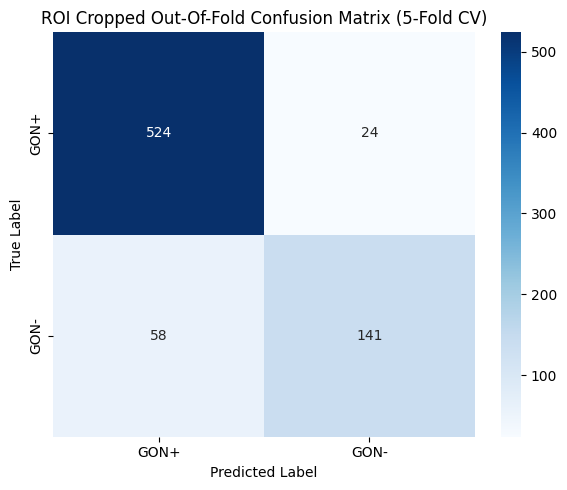

In [4]:
#Out-Of-Fold prediction & confusion matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

oof_df = pd.read_csv("roi_cropped_cv_outputs/roi_cropped_oof_predictions_5fold.csv")

y_true = oof_df["true_label"]
y_pred = oof_df["pred_label"]

class_names = ["GON+", "GON-"]

cm = confusion_matrix(y_true, y_pred)

print("=" * 90)
print("ROI Cropped Out-Of-Fold Classification Report")
print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ROI Cropped Out-Of-Fold Confusion Matrix (5-Fold CV)")
plt.tight_layout()
plt.show()

#### For ROI masked dataset

In [39]:
import pandas as pd
import shutil
from pathlib import Path
from sklearn.model_selection import StratifiedKFold

# ==========================================
# CONFIG
# ==========================================
LABEL_PATH = "Labels.csv"
ROI_ROOT = Path("ROI_MASKED")
SPLIT_PATH = "roi_masked_cv_split"

N_SPLITS = 5
RANDOM_STATE = 42

# ==========================================
# LOAD LABELS
# ==========================================
df = pd.read_csv(LABEL_PATH)
df = df.drop(columns=["Unnamed: 4"], errors="ignore")

df["Image Name"] = df["Image Name"].astype(str).str.strip()
df["label_numeric"] = df["Label"].map({"GON+": 1, "GON-": 0})

# ==========================================
# BUILD SOURCE FILE PATH
# ==========================================
df["Filename"] = df["Image Name"].apply(lambda x: ROI_ROOT / x)

# ==========================================
# CHECK LABEL MAPPING
# ==========================================
if df["label_numeric"].isna().any():
    bad_rows = df[df["label_numeric"].isna()][["Image Name", "Label", "Patient"]]
    raise ValueError(f"Found unmapped labels:\n{bad_rows.head(10)}")

# ==========================================
# CHECK FILE EXISTENCE
# ==========================================
missing_mask = ~df["Filename"].apply(lambda p: Path(p).exists())

print("Total rows:", len(df))
print("Matched masked ROI files:", (~missing_mask).sum())
print("Missing masked ROI files:", missing_mask.sum())

if missing_mask.sum() > 0:
    print("\nFirst 20 missing masked ROI files:")
    print(df.loc[missing_mask, ["Image Name", "Label", "Filename"]].head(20))

# Keep only matched files
df = df.loc[~missing_mask].copy()

if len(df) == 0:
    raise ValueError(
        "No masked ROI files were matched. Please check ROI_ROOT and filenames inside ROI_MASKED."
    )

# ==========================================
# CHECK PATIENT LABEL CONSISTENCY
# ==========================================
patient_label_check = df.groupby("Patient")["label_numeric"].nunique()
bad_patients = patient_label_check[patient_label_check > 1]

if len(bad_patients) > 0:
    raise ValueError(
        f"Some patients have inconsistent labels: {bad_patients.index.tolist()[:10]}"
    )

# ==========================================
# BUILD PATIENT-LEVEL TABLE
# ==========================================
patient_df = (
    df.groupby("Patient", as_index=False)
      .agg(label_numeric=("label_numeric", "first"))
)

print("\n===== PATIENT-LEVEL SUMMARY =====")
print("Total masked ROI images :", len(df))
print("Total patients          :", len(patient_df))
print("Patient label distribution:")
print(patient_df["label_numeric"].value_counts().sort_index())

# ==========================================
# STRATIFIED K-FOLD ON PATIENTS
# ==========================================
skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

def copy_images(dataframe, split_dir):
    total = len(dataframe)
    copied = 0
    missing = 0

    for _, row in dataframe.iterrows():
        src = Path(row["Filename"])
        dst = Path(split_dir) / row["Label"] / src.name

        if src.exists():
            shutil.copy(src, dst)
            copied += 1
        else:
            missing += 1

    return copied, missing

# ==========================================
# GENERATE ALL FOLDS
# ==========================================
for fold_idx, (train_idx, val_idx) in enumerate(
    skf.split(patient_df["Patient"], patient_df["label_numeric"]),
    start=1
):
    print(f"\n===== FOLD {fold_idx} =====")

    train_patients = patient_df.iloc[train_idx]["Patient"]
    val_patients = patient_df.iloc[val_idx]["Patient"]

    train_df = df[df["Patient"].isin(train_patients)].copy()
    val_df = df[df["Patient"].isin(val_patients)].copy()

    overlap = set(train_df["Patient"]).intersection(set(val_df["Patient"]))
    if len(overlap) > 0:
        raise ValueError(f"Patient leakage detected in fold {fold_idx}: {list(overlap)[:10]}")

    print(f"Train patients: {train_df['Patient'].nunique()}, images: {len(train_df)}")
    print(f"Val patients  : {val_df['Patient'].nunique()}, images: {len(val_df)}")

    print("Train label distribution:")
    print(train_df["label_numeric"].value_counts().sort_index())

    print("Val label distribution:")
    print(val_df["label_numeric"].value_counts().sort_index())

    fold_root = Path(SPLIT_PATH) / f"fold_{fold_idx}"
    train_root = fold_root / "train"
    val_root = fold_root / "val"

    for split_root in [train_root, val_root]:
        for label in ["GON+", "GON-"]:
            (split_root / label).mkdir(parents=True, exist_ok=True)

    train_df.to_csv(fold_root / f"train_fold{fold_idx}.csv", index=False)
    val_df.to_csv(fold_root / f"val_fold{fold_idx}.csv", index=False)

    copied_train, missing_train = copy_images(train_df, train_root)
    copied_val, missing_val = copy_images(val_df, val_root)

    print(
        f"✅ Fold {fold_idx} done | "
        f"train: {copied_train} copied, {missing_train} missing | "
        f"val: {copied_val} copied, {missing_val} missing"
    )

print("\n🎉 Masked ROI 5-fold split generated successfully.")

Total rows: 747
Matched masked ROI files: 747
Missing masked ROI files: 0

===== PATIENT-LEVEL SUMMARY =====
Total masked ROI images : 747
Total patients          : 288
Patient label distribution:
label_numeric
0    102
1    186
Name: count, dtype: int64

===== FOLD 1 =====
Train patients: 230, images: 591
Val patients  : 58, images: 156
Train label distribution:
label_numeric
0    157
1    434
Name: count, dtype: int64
Val label distribution:
label_numeric
0     42
1    114
Name: count, dtype: int64
✅ Fold 1 done | train: 591 copied, 0 missing | val: 156 copied, 0 missing

===== FOLD 2 =====
Train patients: 230, images: 599
Val patients  : 58, images: 148
Train label distribution:
label_numeric
0    157
1    442
Name: count, dtype: int64
Val label distribution:
label_numeric
0     42
1    106
Name: count, dtype: int64
✅ Fold 2 done | train: 599 copied, 0 missing | val: 148 copied, 0 missing

===== FOLD 3 =====
Train patients: 230, images: 619
Val patients  : 58, images: 128
Train labe

In [40]:
#Build dataloaders for masked ROI folds
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from pathlib import Path
import torch

# ==========================================
# PARAMETERS
# ==========================================
IMG_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL = "resnet18"
NUM_CLASSES = 1

BATCH_SIZE = 16
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 0.001
NUM_EPOCHS = 15

CV_ROOT = Path("roi_masked_cv_split")
N_FOLDS = 5

# ==========================================
# TRANSFORMS
# ==========================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def build_dataloaders_for_fold(fold_idx, batch_size=BATCH_SIZE):
    train_path = CV_ROOT / f"fold_{fold_idx}" / "train"
    val_path   = CV_ROOT / f"fold_{fold_idx}" / "val"

    if not train_path.exists():
        raise FileNotFoundError(f"Train path not found: {train_path}")
    if not val_path.exists():
        raise FileNotFoundError(f"Val path not found: {val_path}")

    train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
    val_dataset   = datasets.ImageFolder(val_path, transform=val_transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    print(f"===== MASKED ROI FOLD {fold_idx} DATALOADER SUMMARY =====")
    print("Train path:", train_path)
    print("Val path  :", val_path)
    print("Train size:", len(train_dataset))
    print("Val size  :", len(val_dataset))
    print("Class to index:", train_dataset.class_to_idx)
    print()

    return train_dataset, val_dataset, train_loader, val_loader

In [41]:
#Build dataloaders for masked ROI folds
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score, confusion_matrix, f1_score, accuracy_score, average_precision_score

OUTPUT_ROOT = Path("roi_masked_cv_outputs")
MODEL_ROOT = OUTPUT_ROOT / "models"
MODEL_ROOT.mkdir(parents=True, exist_ok=True)

all_fold_results = []
all_oof_rows = []

def compute_binary_metrics(y_true, y_prob, y_pred):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "accuracy": acc,
        "auroc": auc,
        "pr_auc": pr_auc,
        "f1": f1,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

print("Masked ROI 5-fold model training commences...\n")

for fold_idx in range(1, N_FOLDS + 1):
    print(f"\n{'='*50}")
    print(f"MASKED ROI FOLD {fold_idx}/{N_FOLDS}")
    print(f"{'='*50}")

    train_dataset, val_dataset, train_loader, val_loader = build_dataloaders_for_fold(fold_idx)
    print("Class mapping:", train_dataset.class_to_idx)

    model, criterion, optimizer, scheduler = build_model_components()

    best_path = MODEL_ROOT / f"best_model_fold{fold_idx}.pth"
    last_path = MODEL_ROOT / f"last_model_fold{fold_idx}.pth"

    best_val_loss = float("inf")
    best_epoch = -1
    history_rows = []

    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-" * 30)

        train_loss, train_acc = train_one_epoch(model, criterion, optimizer, train_loader)
        val_loss, val_acc, y_true, y_prob, y_pred = validate_one_epoch(model, criterion, val_loader)

        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

        history_rows.append({
            "fold": fold_idx,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        if val_loss < best_val_loss:
            print(f"🌟 Val loss decreased ({best_val_loss:.4f} --> {val_loss:.4f}). Saving model...")
            torch.save(model.state_dict(), best_path)
            best_val_loss = val_loss
            best_epoch = epoch + 1

    torch.save(model.state_dict(), last_path)
    print(f"\nLast model saved to {last_path}")

    model, criterion, optimizer, scheduler = build_model_components()
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    model = model.to(DEVICE)

    val_loss, val_acc, y_true, y_prob, y_pred = validate_one_epoch(model, criterion, val_loader)

    fold_metrics = compute_binary_metrics(y_true, y_prob, y_pred)
    fold_metrics["fold"] = fold_idx
    fold_metrics["best_epoch"] = best_epoch
    fold_metrics["best_val_loss"] = best_val_loss
    fold_metrics["n_val_images"] = len(val_dataset)

    all_fold_results.append(fold_metrics)

    print("\nFold final metrics (best model):")
    for k, v in fold_metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

    val_samples = val_dataset.samples
    if len(val_samples) == len(y_true):
        for (img_path, class_idx), true_label, prob, pred in zip(val_samples, y_true, y_prob, y_pred):
            all_oof_rows.append({
                "fold": fold_idx,
                "image_path": img_path,
                "image_name": Path(img_path).name,
                "true_label": true_label,
                "pred_prob": prob,
                "pred_label": pred,
            })

    fold_history_df = pd.DataFrame(history_rows)
    fold_history_df.to_csv(OUTPUT_ROOT / f"training_history_fold{fold_idx}.csv", index=False)

print("\n🎉 Masked ROI 5-fold training complete!")

results_df = pd.DataFrame(all_fold_results)
results_df.to_csv(OUTPUT_ROOT / "roi_masked_5fold_results.csv", index=False)

summary_df = results_df.drop(columns=["fold"]).agg(["mean", "std"]).T.reset_index()
summary_df.columns = ["metric", "mean", "std"]
summary_df.to_csv(OUTPUT_ROOT / "roi_masked_5fold_summary.csv", index=False)

oof_df = pd.DataFrame(all_oof_rows)
oof_df.to_csv(OUTPUT_ROOT / "roi_masked_oof_predictions_5fold.csv", index=False)

print("\nSaved:")
print(OUTPUT_ROOT / "roi_masked_5fold_results.csv")
print(OUTPUT_ROOT / "roi_masked_5fold_summary.csv")
print(OUTPUT_ROOT / "roi_masked_oof_predictions_5fold.csv")

Masked ROI 5-fold model training commences...


MASKED ROI FOLD 1/5
===== MASKED ROI FOLD 1 DATALOADER SUMMARY =====
Train path: roi_masked_cv_split\fold_1\train
Val path  : roi_masked_cv_split\fold_1\val
Train size: 591
Val size  : 156
Class to index: {'GON+': 0, 'GON-': 1}

Class mapping: {'GON+': 0, 'GON-': 1}

Epoch 1/15
------------------------------
Train Loss: 0.4489 | Train Acc: 0.7547
Val   Loss: 0.3239 | Val   Acc: 0.8333
🌟 Val loss decreased (inf --> 0.3239). Saving model...

Epoch 2/15
------------------------------
Train Loss: 0.1774 | Train Acc: 0.9442
Val   Loss: 0.2320 | Val   Acc: 0.9167
🌟 Val loss decreased (0.3239 --> 0.2320). Saving model...

Epoch 3/15
------------------------------
Train Loss: 0.1359 | Train Acc: 0.9560
Val   Loss: 0.1419 | Val   Acc: 0.9487
🌟 Val loss decreased (0.2320 --> 0.1419). Saving model...

Epoch 4/15
------------------------------
Train Loss: 0.1191 | Train Acc: 0.9628
Val   Loss: 0.2109 | Val   Acc: 0.9295

Epoch 5/15
------------------

#### Cross-vaidated performance on masked ROI data

In [5]:
#Create one-line summary table 
import pandas as pd

masked_df = pd.read_csv("roi_masked_cv_outputs/roi_masked_5fold_results.csv")

def mean_std_str(series):
    return f"{series.mean():.3f} ± {series.std(ddof=1):.3f}"

masked_summary = pd.DataFrame({
    "Feature": ["CNN (ROI Masked)"],
    "AUROC": [mean_std_str(masked_df["auroc"])],
    "Sensitivity (R+)": [mean_std_str(masked_df["specificity"])],  #<--- labels were accidentally swapped, specificity and sensitivity were swapped as a quick patch
    "Specificity (R-)": [mean_std_str(masked_df["sensitivity"])],
    "Accuracy": [mean_std_str(masked_df["accuracy"])],
    "PR-AUC": [mean_std_str(masked_df["pr_auc"])],
    "F1": [mean_std_str(masked_df["f1"])],
})

print("=" * 100)
print("Final patient-level Stratified 5-Fold CV results")
print(masked_summary.to_string(index=False))

masked_summary.to_csv("roi_masked_cv_outputs/roi_masked_final_summary_table.csv", index=False)

Final patient-level Stratified 5-Fold CV results
         Feature         AUROC Sensitivity (R+) Specificity (R-)      Accuracy        PR-AUC            F1
CNN (ROI Masked) 0.988 ± 0.012    0.982 ± 0.013    0.929 ± 0.071 0.967 ± 0.020 0.979 ± 0.018 0.937 ± 0.037


Masked ROI OOF Classification Report
              precision    recall  f1-score   support

        GON+       0.97      0.98      0.98       548
        GON-       0.95      0.92      0.94       199

    accuracy                           0.97       747
   macro avg       0.96      0.95      0.96       747
weighted avg       0.97      0.97      0.97       747



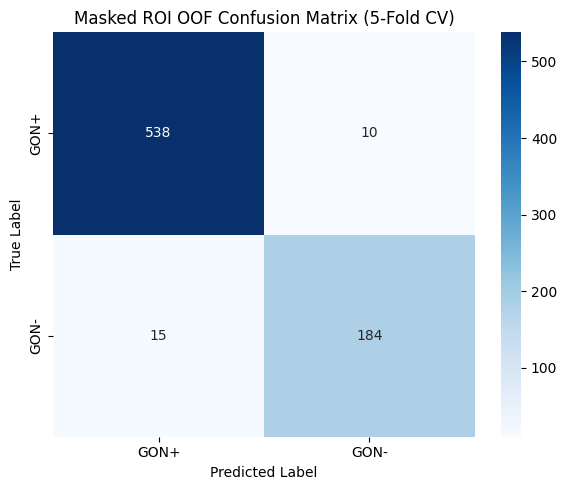

In [6]:
#Out-Of-Fold confusion matrix for masked ROI
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

oof_df = pd.read_csv("roi_masked_cv_outputs/roi_masked_oof_predictions_5fold.csv")

y_true = oof_df["true_label"]
y_pred = oof_df["pred_label"]

class_names = ["GON+", "GON-"]

cm = confusion_matrix(y_true, y_pred)

print("=" * 90)
print("Masked ROI OOF Classification Report")
print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Masked ROI OOF Confusion Matrix (5-Fold CV)")
plt.tight_layout()
plt.show()